In [3]:
!pip install -q scikit-learn==1.2.2 tensorflow seaborn
import os, shutil, random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.resnet import preprocess_input
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 320.5/320.5 kB 6.3 MB/s eta 0:00:00a 0:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-cloud-translate 3.12.1 requires protobuf!=3.20.0,!=3.20.1,!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0dev,>=3.19.5, but you have protobuf 5.29.6 which is incompatible.
ray 2.51.1 requires click!=8.3.0,>=7.0, but you have click 8.3.0 which is incompatible.
bigframes 2.12.0 requires rich<14,>=12.4.4, but you have rich 14.2.0 which is incompatible.
pydrive2 1.21.3 requires cryptography<44, but you have cryptography 46.0.3 which is incompatible.
pydrive2 1.21.3 requires pyOpenSSL<=24.2.1,>=19.1.0, but you have pyopenssl 25.3.0 which is incompatible.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 202

2026-02-25 21:11:46.518245: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772053906.715446      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772053906.768173      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [4]:
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)


In [5]:
SRC_DIR = "/kaggle/input/archive123/DAT-SEGREGATION"
DEST_DIR = "/kaggle/working/ppmi_split"

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS_STAGE1 = 40
EPOCHS_STAGE2 = 60


In [6]:
if not os.path.exists(DEST_DIR):
    for split in ["train", "val", "test"]:
        for cls in ["PD", "NONPD"]:
            os.makedirs(f"{DEST_DIR}/{split}/{cls}", exist_ok=True)

    for cls in ["PD", "NONPD"]:
        files = os.listdir(os.path.join(SRC_DIR, cls))
        train, temp = train_test_split(files, test_size=0.3, random_state=SEED)
        val, test = train_test_split(temp, test_size=0.5, random_state=SEED)

        for f in train:
            shutil.copy(f"{SRC_DIR}/{cls}/{f}", f"{DEST_DIR}/train/{cls}/{f}")
        for f in val:
            shutil.copy(f"{SRC_DIR}/{cls}/{f}", f"{DEST_DIR}/val/{cls}/{f}")
        for f in test:
            shutil.copy(f"{SRC_DIR}/{cls}/{f}", f"{DEST_DIR}/test/{cls}/{f}")

    print("✅ Dataset split completed")


✅ Dataset split completed


In [7]:
train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=True
).flow_from_directory(
    f"{DEST_DIR}/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True
)

val_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input
).flow_from_directory(
    f"{DEST_DIR}/val",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

test_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input
).flow_from_directory(
    f"{DEST_DIR}/test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)


Found 1335 images belonging to 2 classes.
Found 286 images belonging to 2 classes.
Found 287 images belonging to 2 classes.


In [8]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=[0, 1],   
    y=train_gen.classes
)

class_weight_dict = {
    0: class_weights[0],
    1: class_weights[1]
}


In [9]:
base = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze all layers initially
for layer in base.layers:
    layer.trainable = False

x = base.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.4)(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)

output = Dense(1, activation="sigmoid")(x)
model = Model(base.input, output)

model.summary()


I0000 00:00:1772053929.348232      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1772053929.350922      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 14,879,041 (56.76 MB)

 Trainable params: 164,353 (642.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [10]:
model.compile(
    optimizer=Adam(2e-4),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)


In [11]:
callbacks = [
    EarlyStopping(monitor="val_auc", mode="max", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_auc", mode="max", factor=0.5, patience=3),
    ModelCheckpoint("best_ppmi_model.h5", monitor="val_auc", mode="max", save_best_only=True)
]


In [12]:
history1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_STAGE1,
    class_weight=class_weight_dict,
    callbacks=callbacks
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/40


I0000 00:00:1772053933.560522     138 service.cc:148] XLA service 0x7e1278012440 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772053933.561520     138 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1772053933.561544     138 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1772053934.051072     138 cuda_dnn.cc:529] Loaded cuDNN version 90300


 2/84 ━━━━━━━━━━━━━━━━━━━━ 7s 90ms/step - accuracy: 0.8281 - auc: 0.6300 - loss: 0.7225  

I0000 00:00:1772053941.550971     138 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


...

84/84 ━━━━━━━━━━━━━━━━━━━━ 17s 198ms/step - accuracy: 0.8486 - auc: 0.9303 - loss: 0.3316 - val_accuracy: 0.8986 - val_auc: 0.9259 - val_loss: 0.2669 - learning_rate: 2.0000e-04
Epoch 12/40
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.8550 - auc: 0.9180 - loss: 0.3477

84/84 ━━━━━━━━━━━━━━━━━━━━ 17s 201ms/step - accuracy: 0.8548 - auc: 0.9181 - loss: 0.3476 - val_accuracy: 0.9021 - val_auc: 0.9355 - val_loss: 0.2559 - learning_rate: 2.0000e-04
Epoch 13/40
84/84 ━━━━━━━━━━━━━━━━━━━━ 17s 195ms/step - accuracy: 0.8504 - auc: 0.9425 - loss: 0.2992 - val_accuracy: 0.8881 - val_auc: 0.9320 - val_loss: 0.2620 - learning_rate: 2.0000e-04
Epoch 14/40
84/84 ━━━━━━━━━━━━━━━━━━━━ 16s 193ms/step - accuracy: 0.8195 - auc: 0.9188 - loss: 0.3660 - val_accuracy: 0.8881 - val_auc: 0.9282 - val_loss: 0.2671 - learning_rate: 2.0000e-04
Epoch 15/40
84/84 ━━━━━━━━━━━━━━━━━━━━ 16s 194ms/step - accuracy: 0.8589 - auc: 0.9430 - loss: 0.3018 - val_accuracy: 0.8776 - val_auc: 0.9291 - val_loss: 0.2665 - learning_rate: 2.0000e-04
Epoch 16/40
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.8430 - auc: 0.9366 - loss: 0.3181

84/84 ━━━━━━━━━━━━━━━━━━━━ 17s 198ms/step - accuracy: 0.8431 - auc: 0.9366 - loss: 0.3180 - val_accuracy: 0.8916 - val_auc: 0.9413 - val_loss: 0.2449 - learning_rate: 1.0000e-04
Epoch 17/40
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.8810 - auc: 0.9554 - loss: 0.2730

84/84 ━━━━━━━━━━━━━━━━━━━━ 17s 200ms/step - accuracy: 0.8809 - auc: 0.9554 - loss: 0.2731 - val_accuracy: 0.8916 - val_auc: 0.9422 - val_loss: 0.2460 - learning_rate: 1.0000e-04
Epoch 18/40
84/84 ━━━━━━━━━━━━━━━━━━━━ 16s 192ms/step - accuracy: 0.8470 - auc: 0.9380 - loss: 0.3135 - val_accuracy: 0.8881 - val_auc: 0.9388 - val_loss: 0.2506 - learning_rate: 1.0000e-04
Epoch 19/40
84/84 ━━━━━━━━━━━━━━━━━━━━ 16s 195ms/step - accuracy: 0.8663 - auc: 0.9460 - loss: 0.2947 - val_accuracy: 0.8811 - val_auc: 0.9387 - val_loss: 0.2485 - learning_rate: 1.0000e-04
Epoch 20/40
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.8698 - auc: 0.9433 - loss: 0.2928

84/84 ━━━━━━━━━━━━━━━━━━━━ 17s 196ms/step - accuracy: 0.8698 - auc: 0.9433 - loss: 0.2928 - val_accuracy: 0.8986 - val_auc: 0.9424 - val_loss: 0.2417 - learning_rate: 1.0000e-04
Epoch 21/40
84/84 ━━━━━━━━━━━━━━━━━━━━ 16s 195ms/step - accuracy: 0.8695 - auc: 0.9429 - loss: 0.2937 - val_accuracy: 0.8846 - val_auc: 0.9418 - val_loss: 0.2456 - learning_rate: 1.0000e-04
Epoch 22/40
84/84 ━━━━━━━━━━━━━━━━━━━━ 17s 197ms/step - accuracy: 0.8561 - auc: 0.9486 - loss: 0.2879 - val_accuracy: 0.8951 - val_auc: 0.9415 - val_loss: 0.2446 - learning_rate: 1.0000e-04
Epoch 23/40
84/84 ━━━━━━━━━━━━━━━━━━━━ 16s 193ms/step - accuracy: 0.8616 - auc: 0.9556 - loss: 0.2693 - val_accuracy: 0.8881 - val_auc: 0.9406 - val_loss: 0.2418 - learning_rate: 1.0000e-04
Epoch 24/40
84/84 ━━━━━━━━━━━━━━━━━━━━ 16s 190ms/step - accuracy: 0.8681 - auc: 0.9473 - loss: 0.2918 - val_accuracy: 0.8811 - val_auc: 0.9400 - val_loss: 0.2497 - learning_rate: 5.0000e-05
Epoch 25/40
84/84 ━━━━━━━━━━━━━━━━━━━━ 16s 193ms/step - accura

In [13]:
for layer in base.layers[-40:]:
    if not isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = True

model.compile(
    optimizer=Adam(1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

history2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_STAGE2,
    class_weight=class_weight_dict,
    callbacks=callbacks
)


Epoch 1/60
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step - accuracy: 0.8562 - auc: 0.9360 - loss: 0.3179

84/84 ━━━━━━━━━━━━━━━━━━━━ 69s 485ms/step - accuracy: 0.8559 - auc: 0.9358 - loss: 0.3182 - val_accuracy: 0.9196 - val_auc: 0.9522 - val_loss: 0.2232 - learning_rate: 1.0000e-05
Epoch 2/60
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - accuracy: 0.8761 - auc: 0.9494 - loss: 0.2776

84/84 ━━━━━━━━━━━━━━━━━━━━ 25s 293ms/step - accuracy: 0.8760 - auc: 0.9494 - loss: 0.2778 - val_accuracy: 0.8671 - val_auc: 0.9584 - val_loss: 0.3013 - learning_rate: 1.0000e-05
Epoch 3/60
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - accuracy: 0.8493 - auc: 0.9381 - loss: 0.3274

84/84 ━━━━━━━━━━━━━━━━━━━━ 25s 295ms/step - accuracy: 0.8495 - auc: 0.9381 - loss: 0.3271 - val_accuracy: 0.9196 - val_auc: 0.9622 - val_loss: 0.2182 - learning_rate: 1.0000e-05
Epoch 4/60
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - accuracy: 0.9086 - auc: 0.9716 - loss: 0.2098

84/84 ━━━━━━━━━━━━━━━━━━━━ 25s 293ms/step - accuracy: 0.9085 - auc: 0.9716 - loss: 0.2098 - val_accuracy: 0.9161 - val_auc: 0.9653 - val_loss: 0.2201 - learning_rate: 1.0000e-05
Epoch 5/60
84/84 ━━━━━━━━━━━━━━━━━━━━ 24s 288ms/step - accuracy: 0.8792 - auc: 0.9540 - loss: 0.2702 - val_accuracy: 0.9196 - val_auc: 0.9642 - val_loss: 0.2381 - learning_rate: 1.0000e-05
Epoch 6/60
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - accuracy: 0.8832 - auc: 0.9631 - loss: 0.2427

...

84/84 ━━━━━━━━━━━━━━━━━━━━ 25s 294ms/step - accuracy: 0.8991 - auc: 0.9668 - loss: 0.2324 - val_accuracy: 0.9126 - val_auc: 0.9679 - val_loss: 0.2187 - learning_rate: 1.0000e-05
Epoch 8/60
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - accuracy: 0.9065 - auc: 0.9795 - loss: 0.1799

84/84 ━━━━━━━━━━━━━━━━━━━━ 25s 294ms/step - accuracy: 0.9064 - auc: 0.9795 - loss: 0.1801 - val_accuracy: 0.8741 - val_auc: 0.9684 - val_loss: 0.2923 - learning_rate: 1.0000e-05
Epoch 9/60
84/84 ━━━━━━━━━━━━━━━━━━━━ 24s 290ms/step - accuracy: 0.9219 - auc: 0.9825 - loss: 0.1671 - val_accuracy: 0.8322 - val_auc: 0.9481 - val_loss: 0.4334 - learning_rate: 1.0000e-05
Epoch 10/60
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - accuracy: 0.9085 - auc: 0.9790 - loss: 0.1893

84/84 ━━━━━━━━━━━━━━━━━━━━ 25s 294ms/step - accuracy: 0.9087 - auc: 0.9790 - loss: 0.1891 - val_accuracy: 0.8951 - val_auc: 0.9699 - val_loss: 0.2888 - learning_rate: 1.0000e-05
Epoch 11/60
84/84 ━━━━━━━━━━━━━━━━━━━━ 24s 288ms/step - accuracy: 0.9133 - auc: 0.9800 - loss: 0.1784 - val_accuracy: 0.9406 - val_auc: 0.9676 - val_loss: 0.2365 - learning_rate: 1.0000e-05
Epoch 12/60
84/84 ━━━━━━━━━━━━━━━━━━━━ 24s 289ms/step - accuracy: 0.9395 - auc: 0.9881 - loss: 0.1365 - val_accuracy: 0.9266 - val_auc: 0.9683 - val_loss: 0.2127 - learning_rate: 1.0000e-05
Epoch 13/60
84/84 ━━━━━━━━━━━━━━━━━━━━ 24s 288ms/step - accuracy: 0.9608 - auc: 0.9950 - loss: 0.1052 - val_accuracy: 0.9406 - val_auc: 0.9586 - val_loss: 0.2265 - learning_rate: 1.0000e-05
Epoch 14/60
84/84 ━━━━━━━━━━━━━━━━━━━━ 24s 288ms/step - accuracy: 0.9625 - auc: 0.9943 - loss: 0.0911 - val_accuracy: 0.9371 - val_auc: 0.9660 - val_loss: 0.2305 - learning_rate: 5.0000e-06
Epoch 15/60
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - accurac

84/84 ━━━━━━━━━━━━━━━━━━━━ 25s 293ms/step - accuracy: 0.9539 - auc: 0.9941 - loss: 0.0977 - val_accuracy: 0.9161 - val_auc: 0.9709 - val_loss: 0.2440 - learning_rate: 5.0000e-06
Epoch 16/60
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - accuracy: 0.9554 - auc: 0.9942 - loss: 0.0934

84/84 ━━━━━━━━━━━━━━━━━━━━ 25s 293ms/step - accuracy: 0.9555 - auc: 0.9942 - loss: 0.0934 - val_accuracy: 0.9056 - val_auc: 0.9711 - val_loss: 0.2831 - learning_rate: 5.0000e-06
Epoch 17/60
84/84 ━━━━━━━━━━━━━━━━━━━━ 24s 288ms/step - accuracy: 0.9698 - auc: 0.9967 - loss: 0.0725 - val_accuracy: 0.9196 - val_auc: 0.9710 - val_loss: 0.2546 - learning_rate: 5.0000e-06
Epoch 18/60
84/84 ━━━━━━━━━━━━━━━━━━━━ 24s 288ms/step - accuracy: 0.9624 - auc: 0.9943 - loss: 0.0904 - val_accuracy: 0.9056 - val_auc: 0.9694 - val_loss: 0.2634 - learning_rate: 5.0000e-06
Epoch 19/60
84/84 ━━━━━━━━━━━━━━━━━━━━ 24s 288ms/step - accuracy: 0.9754 - auc: 0.9973 - loss: 0.0713 - val_accuracy: 0.9336 - val_auc: 0.9632 - val_loss: 0.2489 - learning_rate: 5.0000e-06
Epoch 20/60
84/84 ━━━━━━━━━━━━━━━━━━━━ 24s 289ms/step - accuracy: 0.9706 - auc: 0.9979 - loss: 0.0609 - val_accuracy: 0.9196 - val_auc: 0.9640 - val_loss: 0.2679 - learning_rate: 2.5000e-06
Epoch 21/60
84/84 ━━━━━━━━━━━━━━━━━━━━ 24s 289ms/step - accura

18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 538ms/step - accuracy: 0.9232 - auc: 0.7706 - loss: 0.2213

✅ Test Accuracy: 91.99%
✅ Test AUC: 0.978
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 129ms/step

Classification Report:

              precision    recall  f1-score   support

       NONPD       0.77      0.94      0.85        67
          PD       0.98      0.91      0.95       220

    accuracy                           0.92       287
   macro avg       0.87      0.93      0.90       287
weighted avg       0.93      0.92      0.92       287



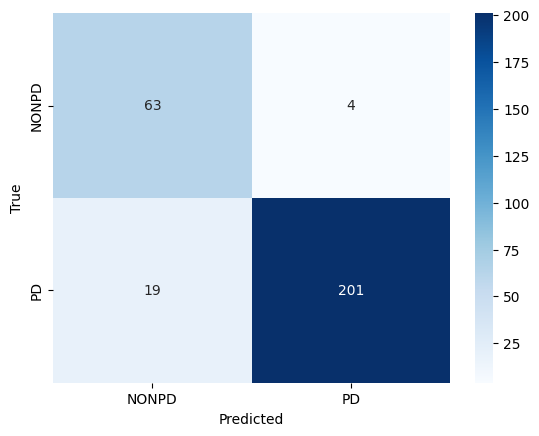

ROC-AUC: 0.97842605156038


In [14]:
model.load_weights("best_ppmi_model.h5")

loss, acc, auc = model.evaluate(test_gen)
print(f"\n✅ Test Accuracy: {acc*100:.2f}%")
print(f"✅ Test AUC: {auc:.3f}")

y_prob = model.predict(test_gen).ravel()
y_pred = (y_prob > 0.5).astype(int)
y_true = test_gen.classes

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=["NONPD", "PD"]))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["NONPD","PD"], yticklabels=["NONPD","PD"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

print("ROC-AUC:", roc_auc_score(y_true, y_prob))


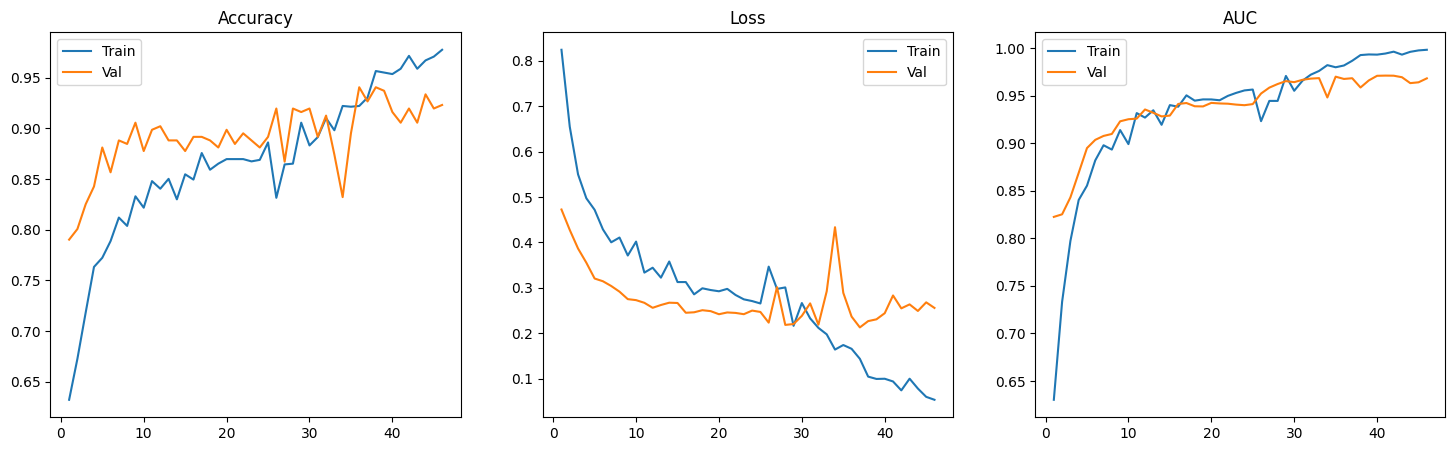

In [15]:
# ============================================================
# 🔹 TRAINING GRAPHS
# ============================================================
acc = history1.history["accuracy"] + history2.history["accuracy"]
val_acc = history1.history["val_accuracy"] + history2.history["val_accuracy"]

loss = history1.history["loss"] + history2.history["loss"]
val_loss = history1.history["val_loss"] + history2.history["val_loss"]

auc = history1.history["auc"] + history2.history["auc"]
val_auc = history1.history["val_auc"] + history2.history["val_auc"]

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
plt.plot(epochs, acc, label="Train")
plt.plot(epochs, val_acc, label="Val")
plt.title("Accuracy")
plt.legend()

plt.subplot(1,3,2)
plt.plot(epochs, loss, label="Train")
plt.plot(epochs, val_loss, label="Val")
plt.title("Loss")
plt.legend()

plt.subplot(1,3,3)
plt.plot(epochs, auc, label="Train")
plt.plot(epochs, val_auc, label="Val")
plt.title("AUC")
plt.legend()

plt.show()


In [16]:
# ============================================================
# SAVE METRICS
# ============================================================
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec  = recall_score(y_true, y_pred)
f1   = f1_score(y_true, y_pred)

metrics_path = os.path.join(DEST_DIR, "metrics.csv")

with open(metrics_path, "w") as f:
    f.write("metric,value\n")
    f.write(f"accuracy,{acc}\n")
    f.write(f"precision,{prec}\n")
    f.write(f"recall,{rec}\n")
    f.write(f"f1,{f1}\n")

print("Metrics saved at:", metrics_path)

Metrics saved at: /kaggle/working/ppmi_split/metrics.csv


In [18]:
# ============================================================
# ZIP RESULTS
# ============================================================
import zipfile
zip_path = "/kaggle/working/vgg16ppmi_results.zip"

with zipfile.ZipFile(zip_path, "w") as z:
    for file in os.listdir(DEST_DIR):
        z.write(os.path.join(DEST_DIR, file), file)

print("✅ ZIP READY:", zip_path)

✅ ZIP READY: /kaggle/working/vgg16ppmi_results.zip
